In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Machine Learning models (we’ll choose later)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score


In [4]:
# Loading the dataset
df = pd.read_csv("https://raw.githubusercontent.com/ek-chris/Practice_datasets/refs/heads/main/EasyVisa%20(1).csv")

# Quick check
row, columns = df.shape
print(f"No of rows: {row} \nNo or columns: {columns}")
df.head()


No of rows: 25480 
No or columns: 12


,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [5]:
# Make a backup copy (safe practice)
df_raw = df.copy()  # preserve original loaded dataframe

# Incase we ned the id column for later mapping:
case_ids = df['case_id'].copy()

# Now drop case_id from the dataframe that will be used for modeling
df = df.drop(columns=['case_id'])
print("Dropped 'case_id'. New shape:", df.shape)
df.head()


Dropped 'case_id'. New shape: (25480, 11)


,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


## Boxplots for All Numeric Columns (excluding target)

Numeric columns to visualize: ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


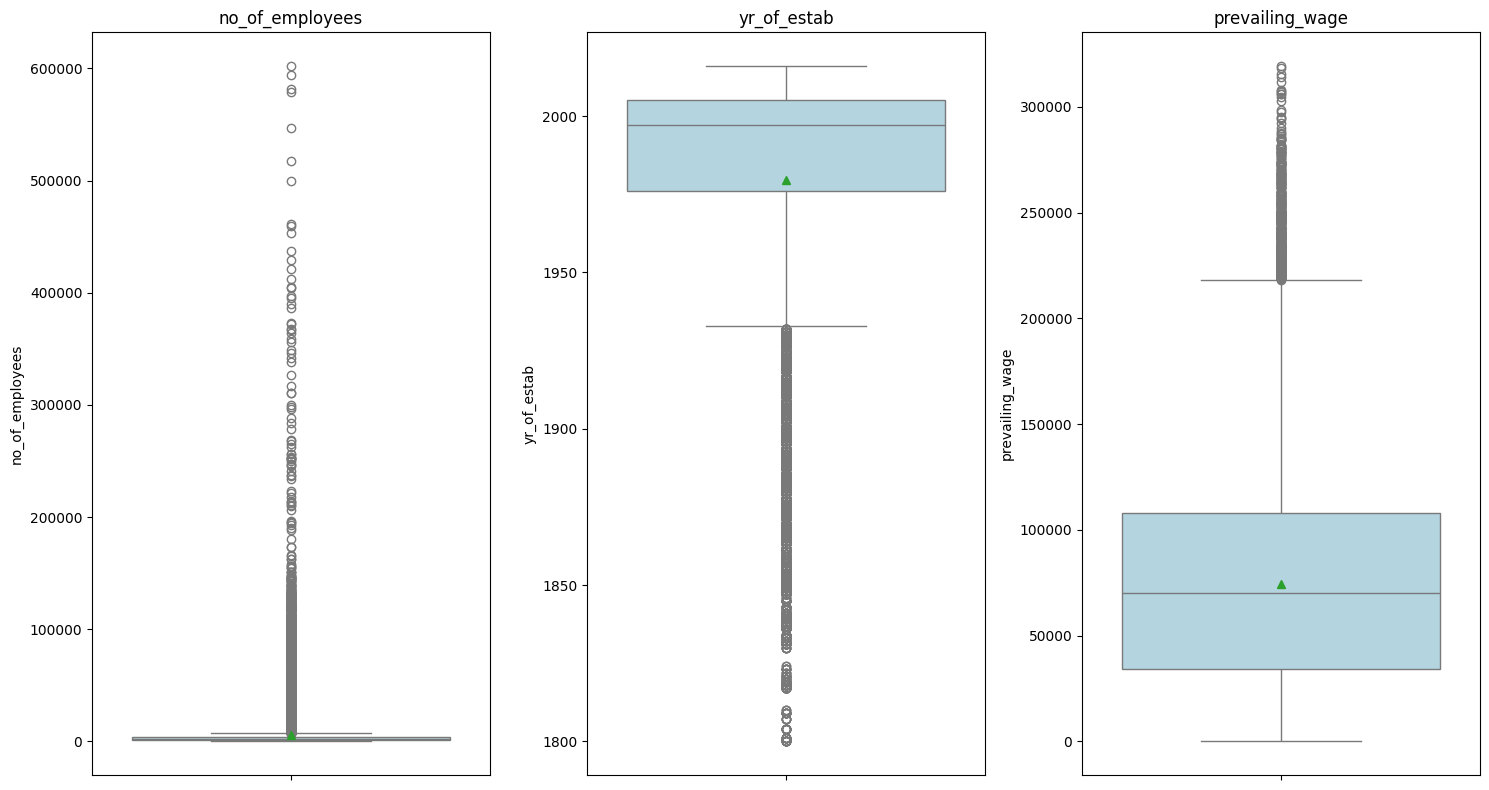

In [6]:
# Select numeric columns
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

# Remove target column if present
if 'case_status' in numeric_columns:
    numeric_columns.remove('case_status')

# Display which numeric columns we’ll plot
print("Numeric columns to visualize:", numeric_columns)

# Plot
plt.figure(figsize=(15, 8))

for i, variable in enumerate(numeric_columns):
    plt.subplot(1, len(numeric_columns), i + 1)
    sns.boxplot(data=df, y=variable, color='lightblue', showmeans=True)
    plt.title(f'{variable}', fontsize=12)
    plt.tight_layout()

plt.show()


In [7]:
def remove_outliers(data, columns):
    """
    Removes outliers from the specified numeric columns using the IQR method.

    Parameters:
    data (pd.DataFrame): The dataframe to remove outliers from.
    columns (list): List of numeric columns to check for outliers.

    Returns:
    pd.DataFrame: Dataframe with outliers removed.
    """
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]
    return data


# Select numeric columns (excluding the target)
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

# Remove the target variable if it somehow appears (safety check)
if 'case_status' in numeric_columns:
    numeric_columns.remove('case_status')

# Remove outliers
cleaned_df = remove_outliers(df, numeric_columns)

print(f"Original data shape: {df.shape}")
print(f"Cleaned data shape: {cleaned_df.shape}")

# Update df
df = cleaned_df.copy()


Original data shape: (25480, 11)
Cleaned data shape: (20530, 11)


Numeric columns to visualize: ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


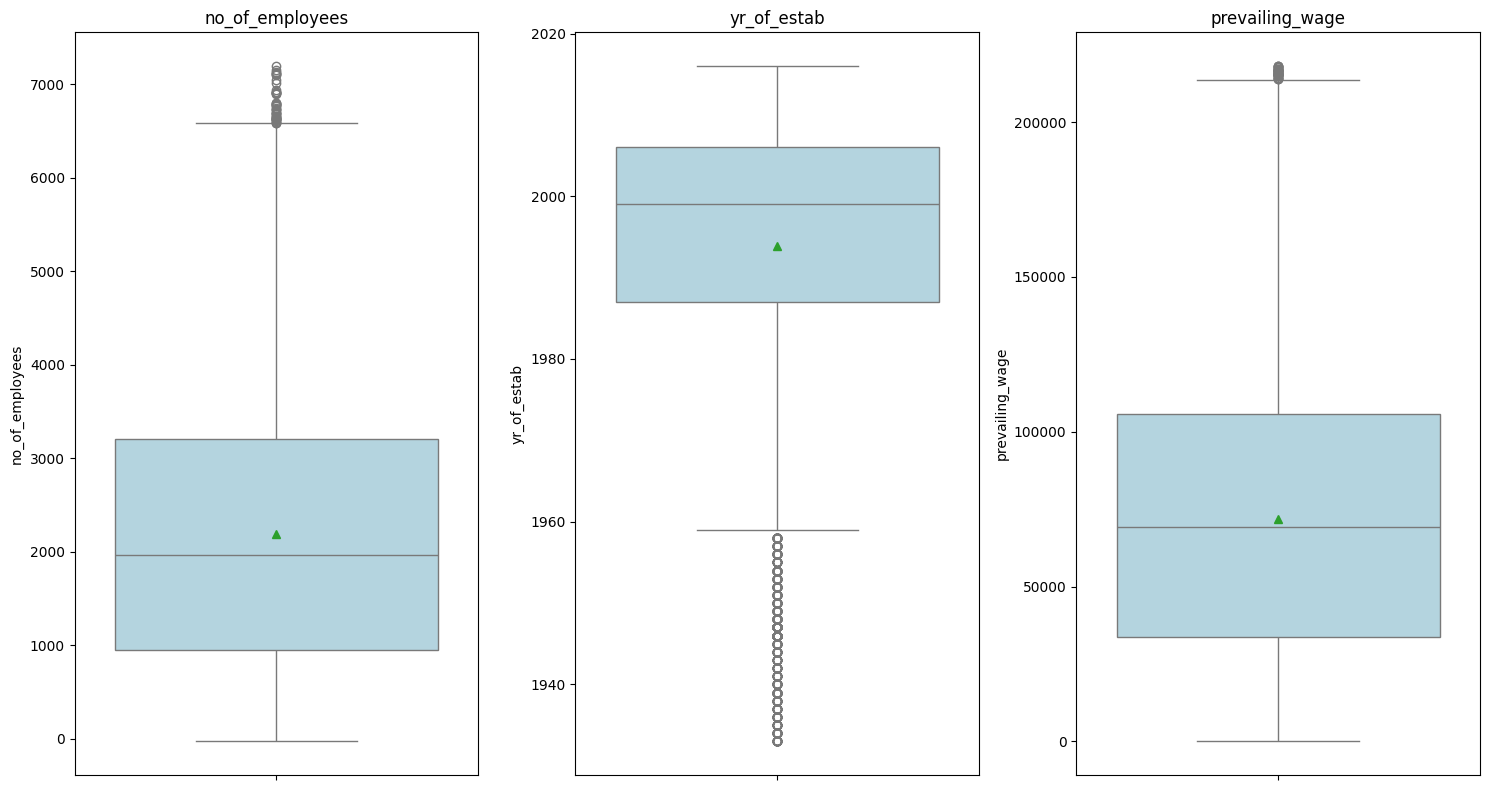

In [8]:
# Select numeric columns
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

# Remove target column if present
if 'case_status' in numeric_columns:
    numeric_columns.remove('case_status')

# Display which numeric columns we’ll plot
print("Numeric columns to visualize:", numeric_columns)

# Plot
plt.figure(figsize=(15, 8))

for i, variable in enumerate(numeric_columns):
    plt.subplot(1, len(numeric_columns), i + 1)
    sns.boxplot(data=df, y=variable, color='lightblue', showmeans=True)
    plt.title(f'{variable}', fontsize=12)
    plt.tight_layout()

plt.show()

## Final Numeric treatment

In [9]:
Q1 = df['no_of_employees'].quantile(0.25)
Q3 = df['no_of_employees'].quantile(0.75)
IQR = Q3 - Q1
upper_cap = Q3 + 1.5 * IQR
lower_cap = Q1 - 1.5 * IQR
df['no_of_employees'] = np.clip(df['no_of_employees'], lower_cap, upper_cap)

# Log-transform prevailing_wage
df['prevailing_wage_log'] = np.log1p(df['prevailing_wage'])


Numeric columns to visualize: ['no_of_employees', 'yr_of_estab', 'prevailing_wage', 'prevailing_wage_log']


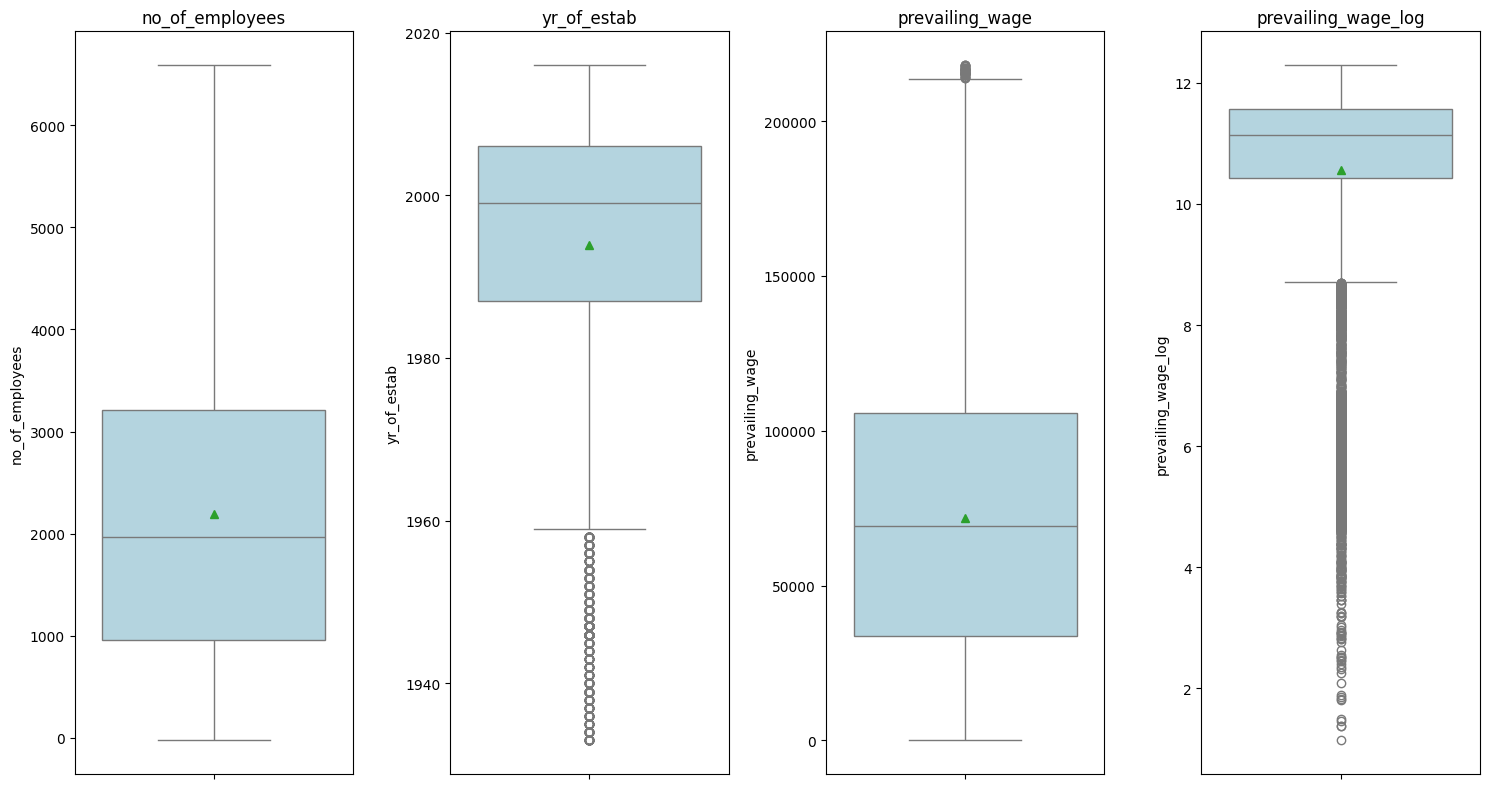

In [10]:
# Select numeric columns
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

# Remove target column if present
if 'case_status' in numeric_columns:
    numeric_columns.remove('case_status')

# Display which numeric columns we’ll plot
print("Numeric columns to visualize:", numeric_columns)

# Plot
plt.figure(figsize=(15, 8))

for i, variable in enumerate(numeric_columns):
    plt.subplot(1, len(numeric_columns), i + 1)
    sns.boxplot(data=df, y=variable, color='lightblue', showmeans=True)
    plt.title(f'{variable}', fontsize=12)
    plt.tight_layout()

plt.show()

In [11]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,prevailing_wage_log
1,Asia,Master's,Y,N,2412.0,2002,Northeast,83425.65,Year,Y,Certified,11.331723
4,Africa,Master's,Y,N,1082.0,2005,South,149907.39,Year,Y,Certified,11.917780
5,Asia,Master's,Y,N,2339.0,2012,South,78252.14,Year,Y,Certified,11.267704
6,Asia,Bachelor's,N,N,4985.0,1994,South,53635.39,Year,Y,Certified,10.889983
8,Asia,Bachelor's,N,N,4810.0,2012,Midwest,74362.19,Year,Y,Certified,11.216716


In [13]:
df = df.drop('prevailing_wage_log')

KeyError: "['prevailing_wage_log'] not found in axis"